## Irreducible mass

In [1]:
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
from scipy.stats import uniform
from scipy.stats import norm
import scipy.stats
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.integrate import quad
import astropy.visualization.hist


# Helps to produce the sampled data from which you retrieve the sampled PDF
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

# Theoretical PDF of f
def pi(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)

def kde_sklearn(xgrd, data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    fitted_kde = kde_skl.fit(data[:, np.newaxis])
    log_pdf = fitted_kde.score_samples(xgrd[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

def pdf_M_irr(f,M_irr,sigma):
    return (np.sqrt(2/np.pi)/sigma) * np.exp(-((M_irr/f-mu)**2)/(2*sigma**2))*(1/f)*(2*f**2-1)/np.sqrt(1-f**2)

def f_M_irr(mu,sigma,W,N):
    M = norm(loc = mu, scale = sigma).rvs(N)
    chi = uniform(loc = 0, scale = W).rvs(N)
    return M*f(chi)

def PlotPDFM_irr(sigma,kernel_bandwidth=[0.1],graph='hist'):
    M = norm(loc = mu, scale = sigma).rvs(N)
    M_irr = M*f(chi)
    plt.figure()
    Mgrid = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,M_grid_samples)
    if graph == 'hist':
        plt.hist(M_irr,density=True,histtype='step',bins=N_bins,label='Sampled')
    else:
        for bw in kernel_bandwidth:
            kde = kde_sklearn(Mgrid,M_irr,bandwidth=bw,kernel=kernel_type)
            plt.plot(Mgrid,kde,label= f'{kernel_type} KDE with bw={bw}')
    pdf_M_irr_theory = []
    for M_IRR in Mgrid:
        integral_value,_ = quad(pdf_M_irr,1/np.sqrt(2),1,args=(M_IRR,sigma))
        pdf_M_irr_theory.append(integral_value)
    plt.plot(Mgrid,pdf_M_irr_theory,label='Theoretical')
    plt.xlabel('$M_{irr}\ [\mu\ units]$')
    plt.ylabel('$pdf(M_{irr})$')
    plt.legend()
    if graph == 'hist':
        plt.title(f'Comparison between theoretical and sampled distribution with $\sigma$={sigma}')
    else:
        plt.title('Comparison between theoretical and KDE distribution')

np.random.seed(31)
mu = 1
sigma = 0.02
W = 1
N = 10000
N_bins = 80
N_objects = 250
kernel_type = 'gaussian'
kernel_bandwidth = 0.01
M_grid_samples = 1000
f_grid = np.linspace(1/np.sqrt(2),1,100)

C:\Anaconda\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


The $M_{irr}$ distribution is given by the $pdf$ of $f(\chi)$ weighted on a Gaussian distribution.
So we can plot the $pdf$ of $f(\chi)$ to have an idea of what the final distribution would look like

C:\Users\edoardo ferocino\AppData\Local\Temp\ipykernel_25296\236267130.py:19: RuntimeWarning: divide by zero encountered in divide
  return 2*(2*f**2-1)/np.sqrt(1-f**2)


Text(0.5, 1.0, 'PDF of the $f$ function')

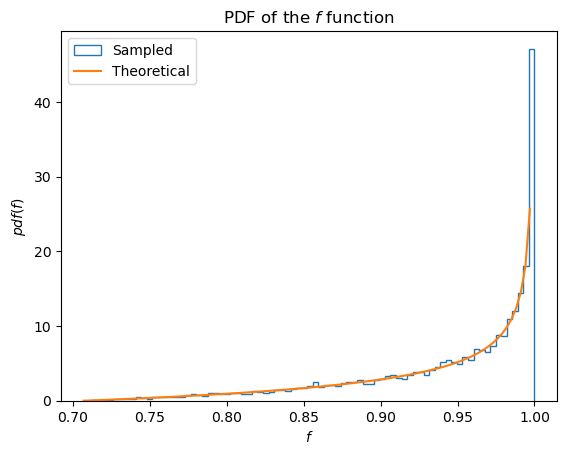

In [8]:
M = norm(loc = mu, scale = sigma).rvs(N)
chi = uniform(loc = 0, scale = W).rvs(N)
M_irr = M*f(chi)

plt.figure()
plt.hist(f(chi),density=True,histtype='step',bins=N_bins,label='Sampled')
plt.plot(f_grid,pi(f_grid),label='Theoretical')
plt.xlabel('$f$')
plt.ylabel('$pdf(f)$')
plt.legend()
plt.title('PDF of the $f$ function')

The total distribution is given by the above distribution weighted by a gaussian. Let's have a look at the pdf with a quick histogram

Text(0.5, 1.0, 'Quick and dirty histogramming')

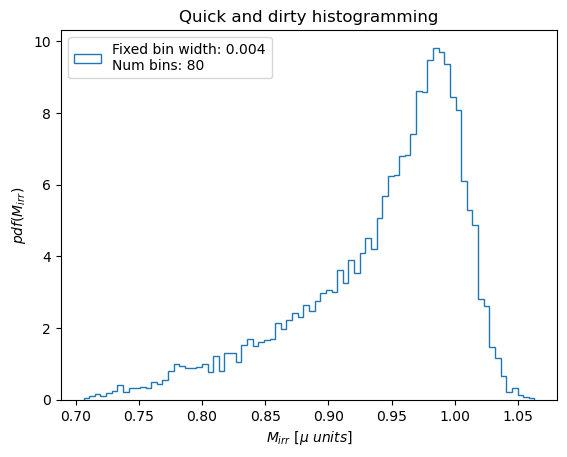

In [9]:
plt.figure()
_,c,h= plt.hist(M_irr,density=True,histtype='step',bins=N_bins)
binwidth1 = c[1]-c[0]
h[0].set_label(f'Fixed bin width: {binwidth1:.3f}\nNum bins: {N_bins}')
plt.legend()
plt.xlabel('$M_{irr}\ [\mu\ units]$')
plt.ylabel(r'$pdf(M_{irr})$')
plt.title('Quick and dirty histogramming')

Now try different histrogramming methods

Text(0.5, 1.0, 'Comparison of different histogramming methods')

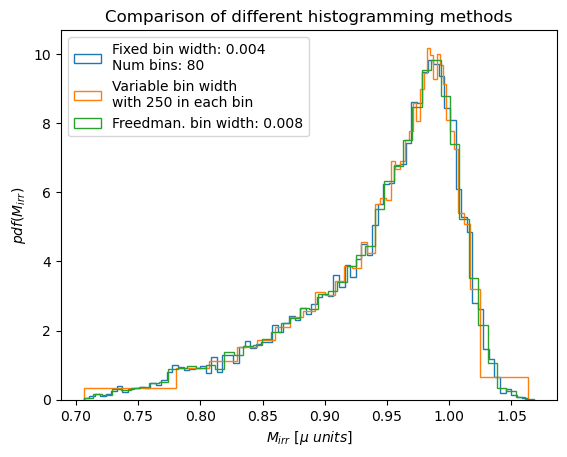

In [10]:
plt.figure()
_,c,h= plt.hist(M_irr,density=True,histtype='step',bins=N_bins)
binwidth1 = c[1]-c[0]
h[0].set_label(f'Fixed bin width: {binwidth1:.3f}\nNum bins: {N_bins}')

bins = np.append(np.sort(M_irr)[::N_objects], np.max(M_irr))
plt.hist(M_irr,density=True,histtype='step',bins=bins,label=f'Variable bin width \nwith {N_objects} in each bin')

_, c, h = astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True)
binwidth2 = c[1]-c[0]
h[0].set_label(f'Freedman. bin width: {binwidth2:.3f}')

plt.legend()
plt.xlabel('$M_{irr}\ [\mu\ units]$')
plt.ylabel('$pdf(M_{irr})$')
plt.title('Comparison of different histogramming methods')

The methods behave similarly. The Freedman method seems to be the "smoothest".

Explore the KDE method now which provides a real smooth solution.

Text(0.5, 1.0, 'Focus on the KDE method')

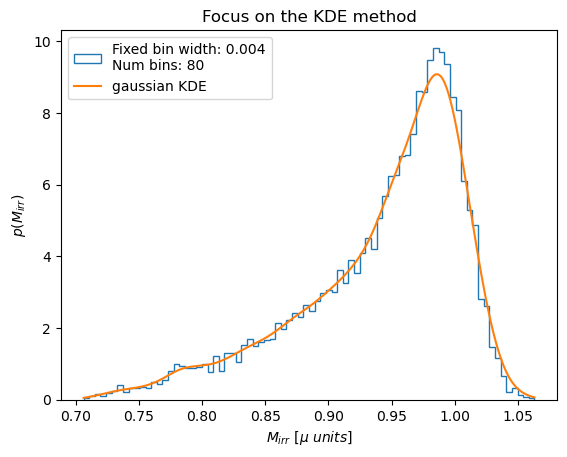

In [11]:
Mgrid = np.linspace(np.min(M_irr), np.max(M_irr),M_grid_samples)
kde = kde_sklearn(Mgrid,M_irr,bandwidth=kernel_bandwidth,kernel=kernel_type)
plt.figure()
plt.hist(M_irr,density=True,histtype='step',bins=N_bins,label = f'Fixed bin width: {binwidth1:.3f}\nNum bins: {N_bins}')
plt.plot(Mgrid,kde,label= f'{kernel_type} KDE')
plt.legend()
plt.xlabel('$M_{irr}\ [\mu\ units]$')
plt.ylabel(r'$p(M_{irr})$')
plt.title('Focus on the KDE method')

Compute the KS statistic of the KS test comparing populations $M_{irr}$ and $M$, $M_{irr}$ and $f$ as a function of $\sigma$.

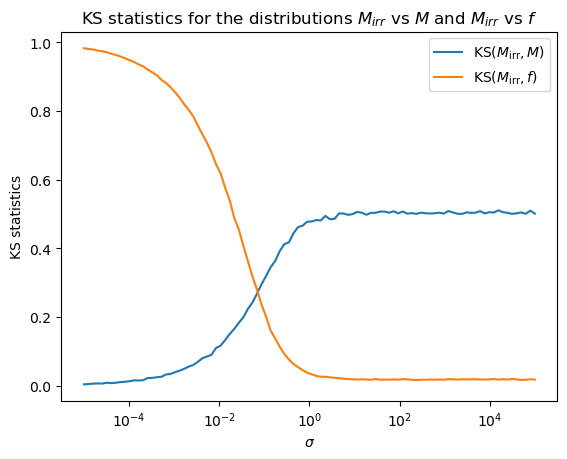

In [12]:
ks2Ms = []
ks2fs = []
s_grid = np.logspace(-5,5,100)
for s in s_grid:
    M = norm(loc = mu, scale = s).rvs(N)
    M_irr = M*f(chi)
    ks2M = scipy.stats.ks_2samp(M_irr/mu,f(chi))
    ks2f = scipy.stats.ks_2samp(M_irr,M)
    ks2Ms.append(ks2M.statistic)
    ks2fs.append(ks2f.statistic)

plt.figure()
plt.plot(s_grid,ks2Ms,label="KS$(M_{\\rm irr}, M)$")
plt.plot(s_grid,ks2fs,label="KS$(M_{\\rm irr}, f)$")
plt.semilogx()
plt.xlabel("$\sigma$")
plt.ylabel('KS statistics')
plt.title('KS statistics for the distributions $M_{irr}$ vs $M$ and $M_{irr}$ vs $f$')
plt.legend();

For low $\sigma$ the distance between the populations $M_{irr}$ and $M$ is very small, suggesting that $M_{irr}$ behaves as $M$. For high $\sigma$ $M_{irr}$ behaves as $f$. Let's see by plots.

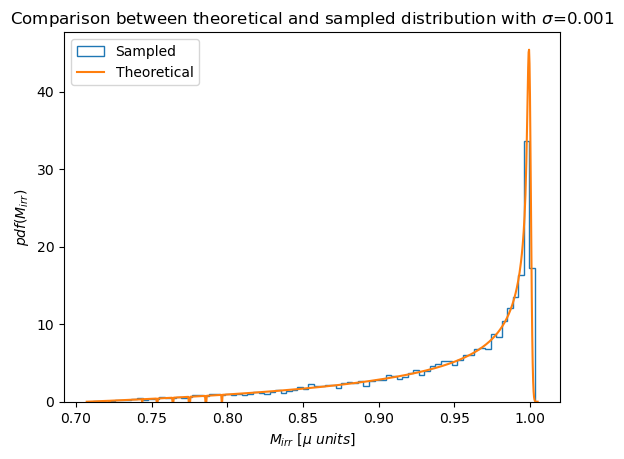

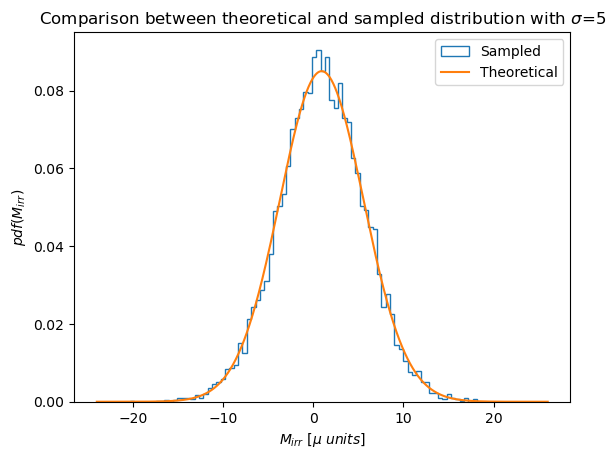

In [13]:
PlotPDFM_irr(0.001)
PlotPDFM_irr(5)

The first graph is very similar to the very first graph that is showed ("PDF of the $f$ function") so is similar to the $f$ distribution. The second is very similar to a Gaussian distribution, which is the $M$ distribution.

Considering the analytical solution of $\pi(f)$, let's compare it with the KDE estimate

C:\Users\edoardo ferocino\AppData\Local\Temp\ipykernel_25296\236267130.py:19: RuntimeWarning: divide by zero encountered in divide
  return 2*(2*f**2-1)/np.sqrt(1-f**2)


Text(0.5, 1.0, 'Comparison between theoretical and KDE distribution of the $f$ function')

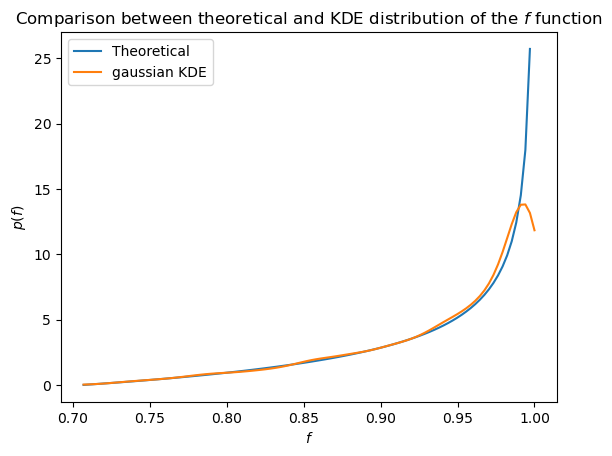

In [14]:
f_grid = np.linspace(1/2**0.5,1,100)
kde = kde_sklearn(f_grid, f(chi),bandwidth=kernel_bandwidth,kernel=kernel_type)
plt.figure()
plt.plot(f_grid,pi(f_grid),label = 'Theoretical')
plt.plot(f_grid,kde,label= f'{kernel_type} KDE')
plt.legend()
plt.xlabel('$f$')
plt.ylabel('$p(f)$')
plt.title('Comparison between theoretical and KDE distribution of the $f$ function')

While now compare the analytical $M_{irr}$ distribution with the KDE reconstruction changing the bandwidth of the KDE algo.

The bandwidth should be choosen "reasonably". Too low and it fluctuates and it becomes noisy, too high and it collapses onto a single Gaussian-ish curve.

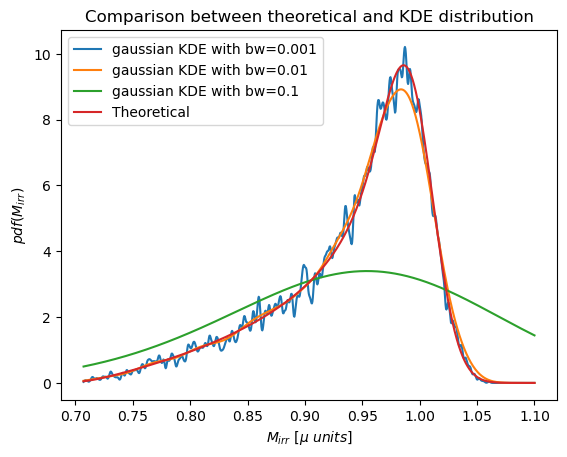

In [15]:
PlotPDFM_irr(0.02,[0.001,0.01,0.1],graph='KDE')